# Long Short-term Memory for Text Generation using PyTorch

This notebook uses LSTM neural network to generate text from Nietzsche's writings. If you find any errors, please let us know. Enjoy!

## Imports

In [1]:
import io
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split


## Dataset

### Get the data
Nietzsche's writing dataset is available online. The following code downloads the dataset (if needed) and loads it.

In [2]:
import urllib.request

url = "https://s3.amazonaws.com/text-datasets/nietzsche.txt"
local_path = Path("nietzsche.txt")

if not local_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, local_path.as_posix())

with io.open(local_path, encoding="utf-8") as f:
    text = f.read().lower()

print("corpus length:", len(text))


corpus length: 600893


### Visualize data

In [3]:
print(text[10:513])

supposing that truth is a woman--what then? is there not ground
for suspecting that all philosophers, in so far as they have been
dogmatists, have failed to understand women--that the terrible
seriousness and clumsy importunity with which they have usually paid
their addresses to truth, have been unskilled and unseemly methods for
winning a woman? certainly she has never allowed herself to be won; and
at present every kind of dogma stands with sad and discouraged mien--if,
indeed, it stands at all!


In [4]:
chars = sorted(list(set(text)))
print("total chars:", len(chars))


total chars: 57


### Clean data
We cut the text in sequences of `maxlen` characters with a jump size of `step`.

In [5]:
# create (character, index) and (index, character) dictionary
char_indices = {c: i for i, c in enumerate(chars)}
indices_char = {i: c for i, c in enumerate(chars)}


In [6]:
# cut the text in semi-redundant sequences of maxlen characters
maxlen = 40
step = 3

sentences = []
next_chars = []

for i in range(0, len(text) - maxlen, step):
    sentences.append(text[i: i + maxlen])
    next_chars.append(text[i + maxlen])

print("nb sequences:", len(sentences))


nb sequences: 200285


### Vectorization
This uses one-hot encoding over characters (so we do **not** use an Embedding layer).

In [7]:
vocab_size = len(chars)
print("Vectorization setup complete.")
print("Example sentence:", sentences[0])
print("Next char:", next_chars[0])
print("vocab_size:", vocab_size)


Vectorization setup complete.
Example sentence: preface


supposing that truth is a woma
Next char: n
vocab_size: 57


## Data pipeline (PyTorch Dataset/DataLoader)
Instead of materializing a giant `(N, maxlen, vocab)` boolean array, we build one-hot tensors on the fly in a `Dataset`. This usually requires much lighter on memory.

In [8]:
class CharDataset(Dataset):
    def __init__(self, sentences, next_chars, char_to_idx, maxlen, vocab_size):
        self.sentences = sentences
        self.next_chars = next_chars
        self.char_to_idx = char_to_idx
        self.maxlen = maxlen
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):

        # x one-hot: (maxlen, vocab_size)
        x = torch.zeros(self.maxlen, self.vocab_size, dtype=torch.float32)
        for t, ch in enumerate(self.sentences[idx]):
            x[t, self.char_to_idx[ch]] = 1.0

        # y class index
        y = self.char_to_idx[self.next_chars[idx]]

        return x, y

dataset = CharDataset(sentences, next_chars, char_indices, maxlen, vocab_size)

# like validation_split=0.2
val_frac = 0.2
val_size = int(len(dataset) * val_frac)
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

BATCH = 128
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, drop_last=False)

len(train_ds), len(val_ds)

(160228, 40057)

## The model
We need a recurrent layer with input shape `(maxlen, vocab_size)` and a dense layer with output size `vocab_size`.

In [9]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=vocab_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x: (batch, seq, vocab)
        out, _ = self.lstm(x)        # out: (batch, seq, hidden)
        out = out[:, -1, :]           # take last time step: (batch, hidden)
        logits = self.fc(out)         # (batch, vocab_size)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = CharLSTM(vocab_size=vocab_size, hidden_size=128).to(device)
model

CharLSTM(
  (lstm): LSTM(57, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=57, bias=True)
)

### Inspect the model

In [10]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(model)
print("Trainable parameters:", count_params(model))


CharLSTM(
  (lstm): LSTM(57, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=57, bias=True)
)
Trainable parameters: 103097


## Train the model
We use `CrossEntropyLoss` (which combines `LogSoftmax` + `NLLLoss`) and Adam optimizer.

We also implement early stopping on validation loss (patience=2).

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


### Sampling helpers (temperature)
We sample from logits with a temperature-scaled softmax.

In [12]:
@torch.no_grad()
def sample_from_logits(logits_1d, temperature=1.0):
    # logits_1d: (vocab_size,)
    if temperature <= 0:
        return int(torch.argmax(logits_1d).item())

    scaled = logits_1d / temperature
    probs = torch.softmax(scaled, dim=0)
    idx = torch.multinomial(probs, num_samples=1)
    return int(idx.item())

@torch.no_grad()
def generate_text(model, seed, length=400, temperature=1.0):
    model.eval()
    generated = seed

    for _ in range(length):
        x = torch.zeros(1, maxlen, vocab_size, dtype=torch.float32, device=device)
        for t, ch in enumerate(generated[-maxlen:]):
            x[0, t, char_indices[ch]] = 1.0

        logits = model(x)[0]  # (vocab_size,)
        next_idx = sample_from_logits(logits, temperature)
        next_char = indices_char[next_idx]
        generated += next_char

    return generated

### Training loop + text generation after each epoch

In [13]:
def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device)  # (batch, seq, vocab)
        yb = yb.to(device)  # (batch,)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_count += bs

    return total_loss / max(1, total_count)


EPOCHS = 60
patience = 2
best_val = float("inf")
bad_epochs = 0

history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    t0 = time.time()

    train_loss = run_epoch(model, train_loader, train=True)
    val_loss = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    dt = time.time() - t0
    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | {dt:.1f}s")

    # "Callback": generate text each epoch like the Keras PrintLoss callback
    print()
    print(f"----- Generating text after Epoch: {epoch+1}")

    start_index = random.randint(0, len(text) - maxlen - 1)
    seed = text[start_index: start_index + maxlen]

    for diversity in [0.5, 1.0]:
        print("----- diversity:", diversity)
        print('----- Generating with seed: "' + seed + '"')
        out = generate_text(model, seed, length=400, temperature=diversity)
        print(out)
        print()

    # Early stopping (monitor val_loss)
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        bad_epochs = 0
        # optionally save best model weights
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs > patience:
            print(f"Early stopping triggered (patience={patience}). Best val_loss={best_val:.4f}")
            break

# Restore best weights (like keeping best epoch)
if 'best_state' in locals():
    model.load_state_dict(best_state)


Epoch 001 | train_loss=2.5837 | val_loss=2.2813 | 70.1s

----- Generating text after Epoch: 1
----- diversity: 0.5
----- Generating with seed: "itics.

209. as to how far the new warli"
itics.

209. as to how far the new warlice for sond the the the then the the the the ersins sing an of at at ame tout and the whathend and and an the the and aon th the non the sereng an the whe the the and and the the the the we the the the atice the coris the poralige pithat ind al of on tha hertaus of ar te the pranet of ind the ill or is and of for the the soror to the and of the the the hangily of and ar ind af are the the whe ins 

----- diversity: 1.0
----- Generating with seed: "itics.

209. as to how far the new warli"
itics.

209. as to how far the new warlikt antorins
n
thhey mmoce the eexacous, munt at iof inde berurevlat=er-od at of oo ttonlam;e!-fals inisa
sfyrevend the ine thod
anaratied nfup od he tore
s the ngreath se for uf ratg be that uont -spinsusiny
--apa!, am and arab
toibew ndeve

### Plot loss curves

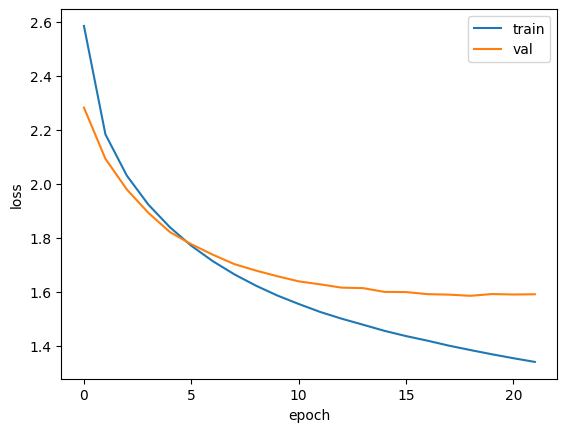

In [14]:
plt.figure()
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()
